In [1]:
import torch
import torch.nn as nn
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import pinn_torch as pinn

In [4]:
#rbf layer as input to the neural network
t_max = 4.0
x_max = 1.0
domain_sizes = [x_max,t_max]
num_centers = 11

#physics_head = pinn.pinn.PhysicsHead(num_spatial=1)
rbf_layer = pinn.pinn.RadialBasisFunction(num_centers=11,domain_sizes=domain_sizes)

num_inputs = rbf_layer.rbf_centers.shape[1]
nodes_per_layer = 32
num_layers = 8
resnn = pinn.pinn.ResidualFullyConnected(num_inputs,num_layers,nodes_per_layer)

physics_layer = pinn.pinn.PhysicsLayer(num_inputs=nodes_per_layer)



In [5]:
net = pinn.pinn.PhysicsHead(
    layers=(rbf_layer,resnn,physics_layer),
    num_spatial=1
)

net.c2 = nn.Parameter(torch.tensor(np.array([1.0])).float())

mse_cost_function = torch.nn.MSELoss() # Mean squared error
optimizer = torch.optim.Adam(net.parameters())

In [6]:
[param for param in net.parameters()]

[Parameter containing:
 tensor([1.], requires_grad=True),
 Parameter containing:
 tensor([[-0.0623,  0.0558, -0.0062,  ..., -0.0662, -0.0300, -0.0811],
         [-0.0447,  0.0335, -0.0577,  ..., -0.0484, -0.0040, -0.0370],
         [ 0.0546,  0.0689,  0.0013,  ..., -0.0010,  0.0430, -0.0258],
         ...,
         [-0.0017,  0.0563,  0.0492,  ..., -0.0029, -0.0830, -0.0744],
         [-0.0646, -0.0702, -0.0792,  ..., -0.0247,  0.0781,  0.0590],
         [ 0.0006,  0.0276,  0.0446,  ...,  0.0820,  0.0444,  0.0182]],
        requires_grad=True),
 Parameter containing:
 tensor([-0.0708,  0.0012, -0.0258, -0.0370,  0.0861,  0.0905,  0.0421, -0.0793,
         -0.0746,  0.0425,  0.0219, -0.0107,  0.0687,  0.0664,  0.0345,  0.0353,
          0.0558,  0.0644, -0.0624,  0.0380,  0.0514, -0.0462,  0.0177,  0.0672,
          0.0102,  0.0470,  0.0629, -0.0002, -0.0614,  0.0148, -0.0647,  0.0873],
        requires_grad=True),
 Parameter containing:
 tensor([[-0.0832, -0.1473,  0.1674,  ..., -0.063

In [7]:
net.to(device)

PhysicsHead(
  (stack): Sequential(
    (0): RadialBasisFunction()
    (1): ResidualFullyConnected(
      (resnn): Sequential(
        (0): Linear(in_features=121, out_features=32, bias=True)
        (1): Tanh()
        (2): LinearSkip(
          (linear): Linear(in_features=32, out_features=32, bias=True)
          (act): Tanh()
        )
        (3): LinearSkip(
          (linear): Linear(in_features=32, out_features=32, bias=True)
          (act): Tanh()
        )
        (4): LinearSkip(
          (linear): Linear(in_features=32, out_features=32, bias=True)
          (act): Tanh()
        )
        (5): LinearSkip(
          (linear): Linear(in_features=32, out_features=32, bias=True)
          (act): Tanh()
        )
        (6): LinearSkip(
          (linear): Linear(in_features=32, out_features=32, bias=True)
          (act): Tanh()
        )
        (7): LinearSkip(
          (linear): Linear(in_features=32, out_features=32, bias=True)
          (act): Tanh()
        )
        

In [8]:
class Oscillator:
    def __init__(self,c2inv=1,c2_true=1):
        self.c2inv = c2inv
        self.c2_true = c2_true
        return
    
    def u0(self,x):
        'Initial displacement at t = 0'
        return x*(1-x)

    def du0(self,x):
        'Initial velocity at t=0, stationary'
        du_arr = np.zeros_like(x)
        return du_arr
    
    def initial_conditions(self,model,x,t):
        u = model(x,t)
        ut, = pinn.differentiation.del_scalar(u,t)
        return ut
    
    def f(self,model,spatial,t):
        # evaluate model
        u = model(spatial,t)
        
        #partial derivatives
        ux,ut = pinn.differentiation.del_scalar(u.sum(),(spatial,t),)
        uxx,utt = pinn.differentiation.del_vector((ux,ut),(spatial,t),)
        
        pde = utt - self.c2inv*uxx
        
        return pde
    
    def get_data(self,x_max,x_num,t_max,t_num):
        lam = np.sqrt(self.c2_true)*np.pi
        
        xgrid = np.linspace(0,x_max,x_num,dtype=np.float32)
        tgrid = np.linspace(0,t_max,t_num,dtype=np.float32)
        
        XX,TT = np.meshgrid(xgrid,tgrid)
        
        u_data = self.u0(XX)*np.cos(lam*TT)
        
        return XX.reshape(-1,1),TT.reshape(-1,1),u_data.reshape(-1,1)


In [9]:
osc = Oscillator(c2inv=net.c2,c2_true=1.7)
osc

In [10]:
#Initial conditions
x_ic = torch.tensor(
    np.random.uniform(low=0.0, high=1.0, size=(500,1))
).float().to(device)
t_ic = torch.tensor(
    np.zeros((500,1)),
    requires_grad=True
).float().to(device)
u_ic = osc.u0(x_ic)
ut_ic = torch.zeros_like(u_ic,requires_grad=True)

#Boundary conditions
xl_bc = torch.tensor(
    np.zeros((500,1))#left tside
).float().to(device)
xr_bc = torch.tensor(
    np.ones((500,1))#right side
).float().to(device)
t_bc = torch.tensor(
    np.random.uniform(low=0.0, high=t_max, size=(500,1))
).float().to(device)
ul_bc = torch.tensor(
    np.zeros((500,1))
).float().to(device)
ur_bc = torch.tensor(
    np.zeros((500,1))
).float().to(device)

#Data
x_max = 1
x_num = 6
t_max = 4
t_num = 11
x_data,t_data,u_data = osc.get_data(x_max,x_num,t_max,t_num)
x_data = torch.tensor(
    x_data
).float().to(device)
t_data = torch.tensor(
    t_data
).float().to(device)
u_data = torch.tensor(
    u_data
).float().to(device)

In [11]:
osc.initial_conditions(net,x_ic,t_ic)

tensor([[0.0040],
        [0.0049],
        [0.0049],
        [0.0110],
        [0.0175],
        [0.0196],
        [0.0038],
        [0.0039],
        [0.0038],
        [0.0046],
        [0.0043],
        [0.0131],
        [0.0046],
        [0.0072],
        [0.0039],
        [0.0130],
        [0.0091],
        [0.0043],
        [0.0085],
        [0.0097],
        [0.0046],
        [0.0040],
        [0.0089],
        [0.0045],
        [0.0149],
        [0.0137],
        [0.0196],
        [0.0147],
        [0.0043],
        [0.0108],
        [0.0115],
        [0.0188],
        [0.0080],
        [0.0195],
        [0.0044],
        [0.0046],
        [0.0038],
        [0.0040],
        [0.0042],
        [0.0129],
        [0.0121],
        [0.0047],
        [0.0040],
        [0.0088],
        [0.0079],
        [0.0058],
        [0.0178],
        [0.0195],
        [0.0040],
        [0.0044],
        [0.0147],
        [0.0125],
        [0.0038],
        [0.0037],
        [0.0102],
        [0

In [12]:
net(x_ic,t_ic)

tensor([[-3.0406e-02],
        [-1.0507e-01],
        [-1.0540e-01],
        [ 3.2927e-02],
        [ 4.1370e-02],
        [ 2.8173e-02],
        [-6.8071e-02],
        [-3.1119e-02],
        [-6.8789e-02],
        [-1.2502e-02],
        [-9.3378e-02],
        [ 3.8369e-02],
        [-1.0006e-01],
        [ 1.4541e-02],
        [-7.0904e-02],
        [ 3.8028e-02],
        [ 2.5608e-02],
        [-9.2272e-02],
        [ 2.2666e-02],
        [ 2.7932e-02],
        [-1.0079e-01],
        [-2.7550e-02],
        [ 2.4640e-02],
        [-1.5222e-02],
        [ 4.1046e-02],
        [ 3.9505e-02],
        [ 3.2476e-02],
        [ 4.0878e-02],
        [-9.2353e-02],
        [ 3.2043e-02],
        [ 3.4496e-02],
        [ 3.8799e-02],
        [ 2.0050e-02],
        [ 3.4416e-02],
        [-9.5562e-02],
        [-1.2632e-02],
        [-6.1023e-02],
        [-8.0083e-02],
        [-8.9978e-02],
        [ 3.8000e-02],
        [ 3.5951e-02],
        [-1.0154e-01],
        [-7.8394e-02],
        [ 2

In [13]:
training_loss_string = '{epoch:6d} Training loss: {loss:g}'
training_loss_string = '{epoch:6d} Training loss: {loss:g} / C-squared {c2:g}'

collocation_size = 1000

losses = []

iterations = 10000
for epoch in range(iterations):
    optimizer.zero_grad() # to make the gradients zero
    
    #Evaluate initial conditions from network
    net_ic_out = net(x_ic,t_ic) # output of u(x0,t=0)
    net_t_ic_out = osc.initial_conditions(net,x_ic,t_ic)
    
    #Evaluate boundary conditions from network
    net_bcl_out = net(xl_bc,t_bc) # output of u(x=xl,t)
    net_bcr_out = net(xr_bc,t_bc) # output of u(x=xr,t)
    
    #loss from initial displacement and inital velocity
    mse_u = mse_cost_function(net_ic_out,u_ic)
    mse_ut = mse_cost_function(net_t_ic_out,ut_ic)
    
    #loss from endpoint boundary conditions
    mse_bcl = mse_cost_function(net_bcl_out, ul_bc)
    mse_bcr = mse_cost_function(net_bcr_out, ur_bc)
    
    # Loss based on PDE
    x_col = torch.tensor(
        np.random.uniform(low=0.0, high=1.0, size=(collocation_size,1)),
        requires_grad=True,
    ).float().to(device)
    t_col = torch.tensor(
        np.random.uniform(low=0.0, high=t_max, size=(collocation_size,1)),
        requires_grad=True,
    ).float().to(device)
    all_zeros = torch.tensor(
        np.zeros((collocation_size,1))
    ).float().to(device)
    
    f_out = osc.f(net,x_col,t_col,) # output of f(x,t)
    mse_f = mse_cost_function(f_out, all_zeros)
    
    #loss from data
    net_data = net(x_data,t_data)
    mse_d = mse_cost_function(net_data, u_data)
    
    # Combining the loss functions
    loss = mse_u + mse_ut + mse_bcl + mse_bcr + mse_f + mse_d
    
    loss.backward() # This is for computing gradients using backward propagation
    optimizer.step() # This is equivalent to : theta_new = theta_old - alpha * derivative of J w.r.t theta
    
    #compute and print the loss
    with torch.autograd.no_grad():
        #print(training_loss_string.format(epoch=epoch,loss=loss))
        
        this_c2 = net.c2.detach().cpu().item()
        this_loss = loss.detach().cpu().item()
        print(training_loss_string.format(epoch=epoch,loss=this_loss,c2=this_c2))
        losses += [this_loss,this_c2]

     0 Training loss: 0.271347 / C-squared 0.999
     1 Training loss: 0.176301 / C-squared 0.998042
     2 Training loss: 0.114312 / C-squared 0.997156
     3 Training loss: 0.0511406 / C-squared 0.996412
     4 Training loss: 0.0660844 / C-squared 0.995738
     5 Training loss: 0.0881028 / C-squared 0.995076
     6 Training loss: 0.0719646 / C-squared 0.994443
     7 Training loss: 0.0517653 / C-squared 0.993865
     8 Training loss: 0.046775 / C-squared 0.99334
     9 Training loss: 0.0509605 / C-squared 0.992848
    10 Training loss: 0.0493593 / C-squared 0.992379
    11 Training loss: 0.0410512 / C-squared 0.991936
    12 Training loss: 0.0366155 / C-squared 0.991524
    13 Training loss: 0.0385441 / C-squared 0.991137
    14 Training loss: 0.0423523 / C-squared 0.990766
    15 Training loss: 0.0437807 / C-squared 0.990405
    16 Training loss: 0.040914 / C-squared 0.990055
    17 Training loss: 0.0361357 / C-squared 0.989719
    18 Training loss: 0.0351514 / C-squared 0.989399
  

   160 Training loss: 0.0285441 / C-squared 0.977017
   161 Training loss: 0.0285154 / C-squared 0.976955
   162 Training loss: 0.0285071 / C-squared 0.976892
   163 Training loss: 0.0285178 / C-squared 0.976829
   164 Training loss: 0.0284706 / C-squared 0.976767
   165 Training loss: 0.0284433 / C-squared 0.976704
   166 Training loss: 0.0283904 / C-squared 0.976642
   167 Training loss: 0.0284209 / C-squared 0.97658
   168 Training loss: 0.0284197 / C-squared 0.976518
   169 Training loss: 0.0284269 / C-squared 0.976455
   170 Training loss: 0.0284865 / C-squared 0.976391
   171 Training loss: 0.0283674 / C-squared 0.976328
   172 Training loss: 0.028392 / C-squared 0.976265
   173 Training loss: 0.0283446 / C-squared 0.976202
   174 Training loss: 0.0283399 / C-squared 0.97614
   175 Training loss: 0.0283563 / C-squared 0.976078
   176 Training loss: 0.0283105 / C-squared 0.976016
   177 Training loss: 0.0283508 / C-squared 0.975953
   178 Training loss: 0.0282967 / C-squared 0.975

   320 Training loss: 0.0236575 / C-squared 0.967073
   321 Training loss: 0.0235704 / C-squared 0.967043
   322 Training loss: 0.0236622 / C-squared 0.967014
   323 Training loss: 0.0235752 / C-squared 0.966987
   324 Training loss: 0.0235055 / C-squared 0.966962
   325 Training loss: 0.0233881 / C-squared 0.966939
   326 Training loss: 0.0234047 / C-squared 0.966919
   327 Training loss: 0.0233061 / C-squared 0.966901
   328 Training loss: 0.0232677 / C-squared 0.966882
   329 Training loss: 0.0233391 / C-squared 0.966865
   330 Training loss: 0.0232828 / C-squared 0.966846
   331 Training loss: 0.0231903 / C-squared 0.966828
   332 Training loss: 0.02315 / C-squared 0.966811
   333 Training loss: 0.022987 / C-squared 0.966798
   334 Training loss: 0.022954 / C-squared 0.966786
   335 Training loss: 0.0230443 / C-squared 0.966775
   336 Training loss: 0.0229177 / C-squared 0.966765
   337 Training loss: 0.0229256 / C-squared 0.966756
   338 Training loss: 0.0228701 / C-squared 0.9667

   480 Training loss: 0.0217599 / C-squared 0.96269
   481 Training loss: 0.0216388 / C-squared 0.962668
   482 Training loss: 0.0217387 / C-squared 0.962645
   483 Training loss: 0.0218086 / C-squared 0.962626
   484 Training loss: 0.0217396 / C-squared 0.962604
   485 Training loss: 0.0216736 / C-squared 0.962582
   486 Training loss: 0.0217734 / C-squared 0.962563
   487 Training loss: 0.0218172 / C-squared 0.962537
   488 Training loss: 0.0219012 / C-squared 0.962509
   489 Training loss: 0.0219713 / C-squared 0.962479
   490 Training loss: 0.0218299 / C-squared 0.962454
   491 Training loss: 0.0216854 / C-squared 0.96243
   492 Training loss: 0.0216201 / C-squared 0.96241
   493 Training loss: 0.021611 / C-squared 0.96239
   494 Training loss: 0.0216365 / C-squared 0.962368
   495 Training loss: 0.0215985 / C-squared 0.962349
   496 Training loss: 0.0215714 / C-squared 0.962328
   497 Training loss: 0.0215162 / C-squared 0.962308
   498 Training loss: 0.0215988 / C-squared 0.96228

   640 Training loss: 0.0214257 / C-squared 0.958399
   641 Training loss: 0.0213917 / C-squared 0.95837
   642 Training loss: 0.0214048 / C-squared 0.958345
   643 Training loss: 0.0212341 / C-squared 0.95832
   644 Training loss: 0.0212617 / C-squared 0.9583
   645 Training loss: 0.0212917 / C-squared 0.958283
   646 Training loss: 0.0215484 / C-squared 0.958261
   647 Training loss: 0.0215736 / C-squared 0.958242
   648 Training loss: 0.0215835 / C-squared 0.958216
   649 Training loss: 0.021373 / C-squared 0.958193
   650 Training loss: 0.0212042 / C-squared 0.958167
   651 Training loss: 0.0212967 / C-squared 0.958141
   652 Training loss: 0.021323 / C-squared 0.958116
   653 Training loss: 0.0214513 / C-squared 0.958089
   654 Training loss: 0.0214436 / C-squared 0.958063
   655 Training loss: 0.0214648 / C-squared 0.958035
   656 Training loss: 0.0213647 / C-squared 0.958015
   657 Training loss: 0.0212252 / C-squared 0.957995
   658 Training loss: 0.0211981 / C-squared 0.957975

...

  9293 Training loss: 0.00158999 / C-squared 1.6954
  9294 Training loss: 0.0014169 / C-squared 1.69543
  9295 Training loss: 0.00107624 / C-squared 1.6954
  9296 Training loss: 0.00162495 / C-squared 1.69546
  9297 Training loss: 0.001615 / C-squared 1.69544
  9298 Training loss: 0.00140146 / C-squared 1.69545
  9299 Training loss: 0.00109926 / C-squared 1.69547
  9300 Training loss: 0.001301 / C-squared 1.69543
  9301 Training loss: 0.00201982 / C-squared 1.69546
  9302 Training loss: 0.00120478 / C-squared 1.69545
  9303 Training loss: 0.00083382 / C-squared 1.69546
  9304 Training loss: 0.00167286 / C-squared 1.69547
  9305 Training loss: 0.00213638 / C-squared 1.69547
  9306 Training loss: 0.00153094 / C-squared 1.69546
  9307 Training loss: 0.00100734 / C-squared 1.69547
  9308 Training loss: 0.00108144 / C-squared 1.69546
  9309 Training loss: 0.00186693 / C-squared 1.69545
  9310 Training loss: 0.00199256 / C-squared 1.69548
  9311 Training loss: 0.00125613 / C-squared 1.69545


  9453 Training loss: 0.000954122 / C-squared 1.69682
  9454 Training loss: 0.00104773 / C-squared 1.69683
  9455 Training loss: 0.00105544 / C-squared 1.69687
  9456 Training loss: 0.00109802 / C-squared 1.69681
  9457 Training loss: 0.00111425 / C-squared 1.69688
  9458 Training loss: 0.000838711 / C-squared 1.69684
  9459 Training loss: 0.000805397 / C-squared 1.69686
  9460 Training loss: 0.000837878 / C-squared 1.6969
  9461 Training loss: 0.000749624 / C-squared 1.69687
  9462 Training loss: 0.000769633 / C-squared 1.69691
  9463 Training loss: 0.000946495 / C-squared 1.69688
  9464 Training loss: 0.00101723 / C-squared 1.69693
  9465 Training loss: 0.00073329 / C-squared 1.6969
  9466 Training loss: 0.000901596 / C-squared 1.69694
  9467 Training loss: 0.0010078 / C-squared 1.69693
  9468 Training loss: 0.000857367 / C-squared 1.69695
  9469 Training loss: 0.000897902 / C-squared 1.69697
  9470 Training loss: 0.000840264 / C-squared 1.69695
  9471 Training loss: 0.000546917 / C-

  9613 Training loss: 0.00116117 / C-squared 1.69744
  9614 Training loss: 0.00135311 / C-squared 1.69757
  9615 Training loss: 0.00199404 / C-squared 1.69746
  9616 Training loss: 0.001528 / C-squared 1.69755
  9617 Training loss: 0.000777136 / C-squared 1.6975
  9618 Training loss: 0.000618124 / C-squared 1.69754
  9619 Training loss: 0.000697554 / C-squared 1.69755
  9620 Training loss: 0.000783351 / C-squared 1.69755
  9621 Training loss: 0.000933531 / C-squared 1.69758
  9622 Training loss: 0.00114525 / C-squared 1.69753
  9623 Training loss: 0.00154647 / C-squared 1.69761
  9624 Training loss: 0.00125794 / C-squared 1.69757
  9625 Training loss: 0.00115487 / C-squared 1.6976
  9626 Training loss: 0.00117649 / C-squared 1.6976
  9627 Training loss: 0.000844851 / C-squared 1.6976
  9628 Training loss: 0.000785056 / C-squared 1.69764
  9629 Training loss: 0.000994148 / C-squared 1.69756
  9630 Training loss: 0.0012294 / C-squared 1.69766
  9631 Training loss: 0.00144186 / C-squared 

  9773 Training loss: 0.0012168 / C-squared 1.6978
  9774 Training loss: 0.00128849 / C-squared 1.69775
  9775 Training loss: 0.00142111 / C-squared 1.69778
  9776 Training loss: 0.00112778 / C-squared 1.69775
  9777 Training loss: 0.000864297 / C-squared 1.69774
  9778 Training loss: 0.00114519 / C-squared 1.69777
  9779 Training loss: 0.00188901 / C-squared 1.69769
  9780 Training loss: 0.00200872 / C-squared 1.69774
  9781 Training loss: 0.0013015 / C-squared 1.69769
  9782 Training loss: 0.00106711 / C-squared 1.69773
  9783 Training loss: 0.00146592 / C-squared 1.69766
  9784 Training loss: 0.00158891 / C-squared 1.69772
  9785 Training loss: 0.00133515 / C-squared 1.69767
  9786 Training loss: 0.00137856 / C-squared 1.6977
  9787 Training loss: 0.00185741 / C-squared 1.69764
  9788 Training loss: 0.00206066 / C-squared 1.69775
  9789 Training loss: 0.00200299 / C-squared 1.69762
  9790 Training loss: 0.00155899 / C-squared 1.69766
  9791 Training loss: 0.00167936 / C-squared 1.69

  9933 Training loss: 0.00109613 / C-squared 1.69902
  9934 Training loss: 0.000987076 / C-squared 1.69906
  9935 Training loss: 0.000918759 / C-squared 1.69902
  9936 Training loss: 0.000971288 / C-squared 1.69904
  9937 Training loss: 0.00158435 / C-squared 1.69904
  9938 Training loss: 0.00172667 / C-squared 1.69904
  9939 Training loss: 0.00138225 / C-squared 1.69907
  9940 Training loss: 0.000810434 / C-squared 1.69898
  9941 Training loss: 0.00130396 / C-squared 1.69906
  9942 Training loss: 0.00242573 / C-squared 1.69895
  9943 Training loss: 0.00285175 / C-squared 1.69907
  9944 Training loss: 0.0032117 / C-squared 1.69893
  9945 Training loss: 0.00442515 / C-squared 1.69901
  9946 Training loss: 0.00548362 / C-squared 1.69892
  9947 Training loss: 0.00450684 / C-squared 1.69895
  9948 Training loss: 0.00253382 / C-squared 1.69888
  9949 Training loss: 0.00194622 / C-squared 1.69881
  9950 Training loss: 0.00352031 / C-squared 1.69883
  9951 Training loss: 0.00374094 / C-square

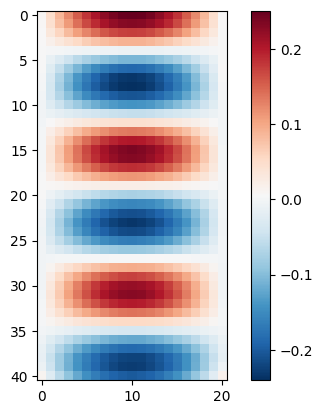

In [14]:
x_mesh = 21
t_mesh = 41
xgrid = np.linspace(0,1,x_mesh,dtype=np.float32)
tgrid = np.linspace(0,t_max,t_mesh,dtype=np.float32)

#xgrid = Variable(torch.from_numpy(xgrid).float(), requires_grad=False).to(device)
#tgrid = Variable(torch.from_numpy(tgrid).float(), requires_grad=False).to(device)

XX,TT = np.meshgrid(xgrid,tgrid)
X = torch.tensor(
    XX.reshape(-1,1),
    device=device
).float()
T = torch.tensor(
    TT.reshape(-1,1),
    device=device
).float()
U = net(X,T)
UU = U.reshape(t_mesh,x_mesh).detach().cpu()


# uplot_0 = np.zeros((t_mesh,x_mesh))

# for nt,t in enumerate(tgrid):
#     for nx,x in enumerate(xgrid):
#         #print(x[None])
#         X = Variable(torch.from_numpy(x[None,None]).float(), requires_grad=False).to(device)
#         T = Variable(torch.from_numpy(t[None,None]).float(), requires_grad=False).to(device)
#         #print(x)
#         uplot_0[nt,nx] = net(X,T)
plt.imshow(UU,cmap='RdBu_r')
plt.colorbar()

In [15]:
colors_x = [[0,0.5,cval] for cval in np.linspace(0,1,t_mesh)]
colors_t = [[0.5,0,cval] for cval in np.linspace(0,1,x_mesh)]

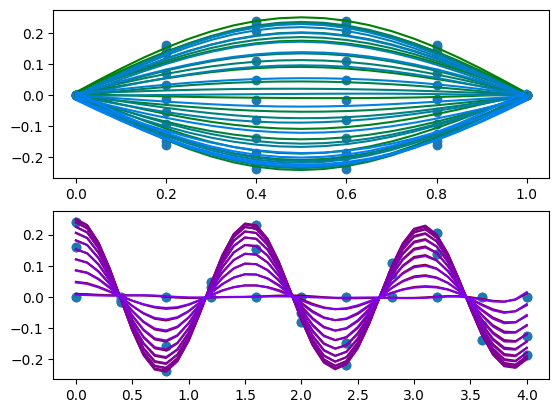

In [16]:
fig,ax = plt.subplots(2,1)
t_offset = 0#0.5

#ax[0].axhline(y=0,ls=':',c='k')
#ax[0].axhline(y=t_offset,ls=':',c='k')
#ax[0].axvline(x=0.5,ls=':',c='k')

for n,(l,c) in enumerate(zip(UU,colors_x)):
    #print(c)
    ax[0].plot(xgrid,l+n*0.,c=c)
for n,(l,c) in enumerate(zip(UU.T,colors_t)):
    #print(c)
    ax[1].plot(tgrid,l+t_offset+n*0.,c=c)
    
ax[0].scatter(x_data.cpu(),u_data.cpu())
ax[1].scatter(t_data.cpu(),u_data.cpu())

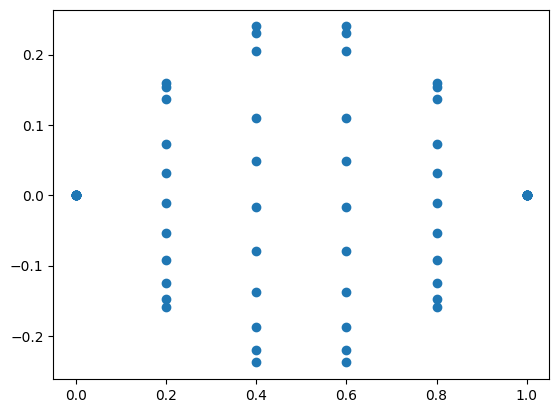

In [17]:
plt.scatter(x_data.cpu(),u_data.cpu())

In [18]:
t_data

tensor([[0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.4000],
        [0.4000],
        [0.4000],
        [0.4000],
        [0.4000],
        [0.4000],
        [0.8000],
        [0.8000],
        [0.8000],
        [0.8000],
        [0.8000],
        [0.8000],
        [1.2000],
        [1.2000],
        [1.2000],
        [1.2000],
        [1.2000],
        [1.2000],
        [1.6000],
        [1.6000],
        [1.6000],
        [1.6000],
        [1.6000],
        [1.6000],
        [2.0000],
        [2.0000],
        [2.0000],
        [2.0000],
        [2.0000],
        [2.0000],
        [2.4000],
        [2.4000],
        [2.4000],
        [2.4000],
        [2.4000],
        [2.4000],
        [2.8000],
        [2.8000],
        [2.8000],
        [2.8000],
        [2.8000],
        [2.8000],
        [3.2000],
        [3.2000],
        [3.2000],
        [3.2000],
        [3.2000],
        [3.2000],
        [3.6000],
        [3

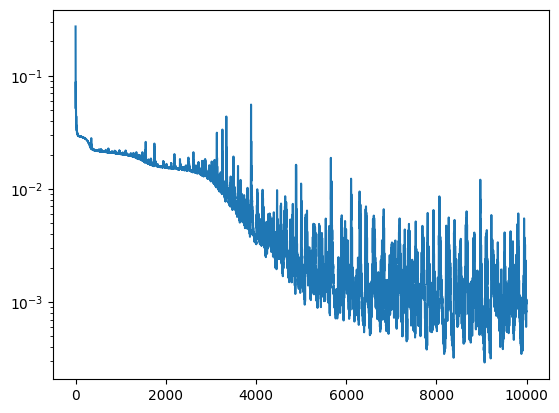

In [19]:
loss_vals = np.array(losses[::2])
plt.plot(loss_vals)
ax=plt.gca()
ax.set_yscale('log')

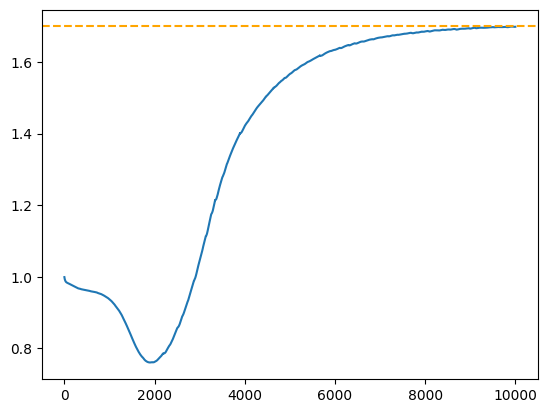

In [23]:
c2_vals = np.array(losses[1::2])
plt.plot(c2_vals)
plt.gca().axhline(osc.c2_true,ls='--',c='orange')